<a href="https://colab.research.google.com/github/tanvibeer12/Pattern-Recognition/blob/main/CM23020_02_pr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

from google.colab import files

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Dataset Loaded Successfully")
print(df.head())

print("Dataset Shape:", df.shape)

Saving diabetes.csv to diabetes (3).csv
Dataset Loaded Successfully
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Dataset Shape: (768, 9)


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

print("Missing values handled successfully.")

Missing values handled successfully.


In [ ]:
target_column = df.columns[-1]

print("Target Column:", target_column)

Target Column: Outcome


In [ ]:
X = df.drop(target_column, axis=1)
y = df[target_column]

In [ ]:
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

print(X.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  


In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio")
print(pca.explained_variance_ratio_)

Explained Variance Ratio
[0.26179749 0.21640127]


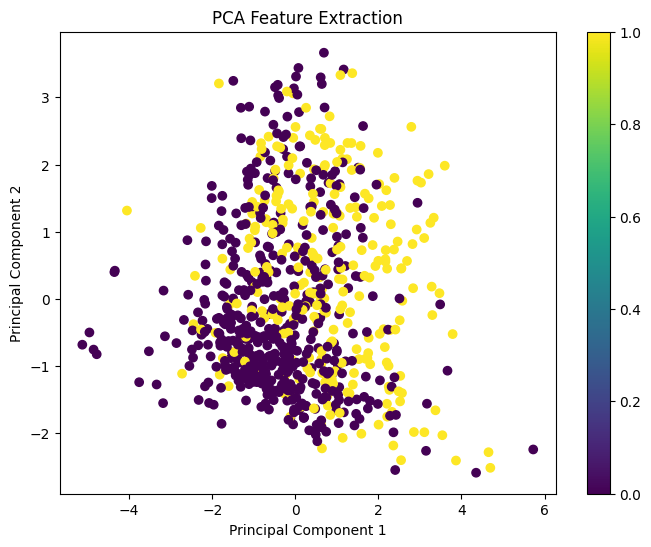

In [ ]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Feature Extraction")

plt.colorbar(scatter)

plt.show()

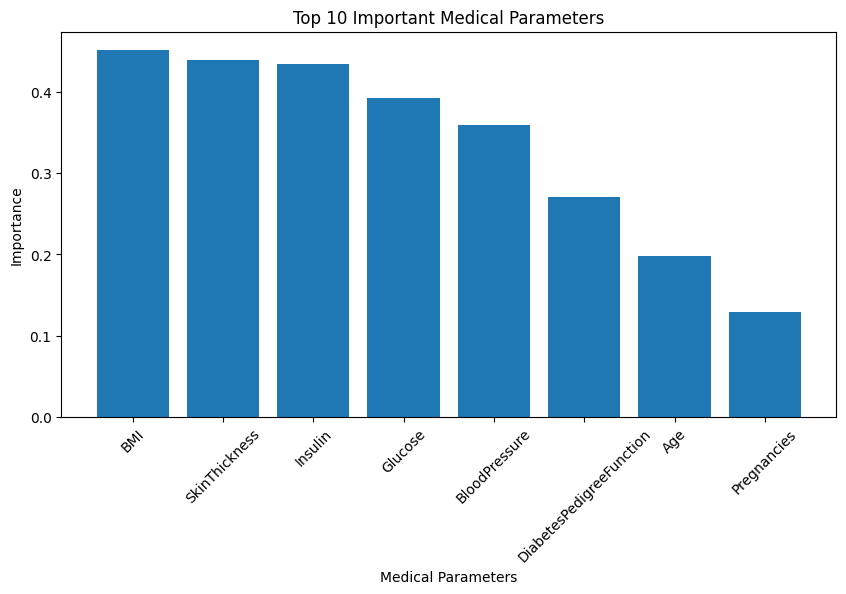

In [ ]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,5))

plt.bar(top10["Feature"], top10["Importance"])

plt.xticks(rotation=45)

plt.xlabel("Medical Parameters")
plt.ylabel("Importance")
plt.title("Top 10 Important Medical Parameters")

plt.show()